In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(filepath_or_buffer="ai_student_impact_dataset.csv")
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


### Data Preparation

In [4]:
df.columns = [column.lower() for column in df.columns]
df.head()

,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  50000 non-null  int64  
 1   major_category              50000 non-null  str    
 2   year_of_study               50000 non-null  str    
 3   pre_semester_gpa            50000 non-null  float64
 4   weekly_genai_hours          50000 non-null  float64
 5   primary_use_case            50000 non-null  str    
 6   prompt_engineering_skill    50000 non-null  str    
 7   tool_diversity              50000 non-null  int64  
 8   paid_subscription           50000 non-null  bool   
 9   traditional_study_hours     50000 non-null  float64
 10  perceived_ai_dependency     50000 non-null  int64  
 11  institutional_policy        50000 non-null  str    
 12  anxiety_level_during_exams  50000 non-null  int64  
 13  post_semester_gpa           50000 non-null

There is no missing values in our dataset.

#### Detecting Outliers
I will try to find outliers in our dataset by using IQR and Z-score for features such as `weekly_genai_hours`, `pre_semester_gpa` and `post_semester_gpa` by defining one function for each method and then reapplying them whenever needed.  

In [6]:
def z_score(df: pd.DataFrame, column_name: str) -> pd.Series:
	mean = df[column_name].mean()
	std = df[column_name].std()

	z_scores = (df[column_name] - mean) / std
	return z_scores

def calculate_iqr(df: pd.DataFrame, column_name: str) -> tuple[float, float, float]:
	Q1 = df[column_name].quantile(0.25)
	Q3 = df[column_name].quantile(0.75)
	IQR = Q3 - Q1

	lower_bound = Q1 - 1.5 * IQR
	upper_bound = Q3 + 1.5 * IQR

	return IQR, lower_bound, upper_bound

In [7]:
IQR, lower_bound, upper_bound = calculate_iqr(df=df, column_name="weekly_genai_hours")
def decide_iqr_outlier_helper(value: int | float) -> str:
    return "outlier" if value > upper_bound or value < lower_bound else "not_outlier"

def decide_z_score_outlier_helper(z_score: int | float) -> str:
    return "outlier" if np.abs(z_score) > 3 else "not_outlier"

df["weekly_genai_hours_outlier_iqr"] = df["weekly_genai_hours"].map(decide_iqr_outlier_helper)
df["weekly_genai_hours_z_score"] = (
    z_score(df=df, column_name="weekly_genai_hours")
)
df["weekly_genai_hours_outlier_z_score"] = df["weekly_genai_hours_z_score"].map(decide_z_score_outlier_helper)


df.head(20)


,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,weekly_genai_hours_outlier_iqr,weekly_genai_hours_z_score,weekly_genai_hours_outlier_z_score
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,not_outlier,1.799657,not_outlier
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,not_outlier,-0.883700,not_outlier
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,not_outlier,1.551758,not_outlier
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,not_outlier,-0.799052,not_outlier
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,not_outlier,0.104269,not_outlier
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High,not_outlier,-0.233116,not_outlier
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium,outlier,2.779162,not_outlier
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium,not_outlier,-0.374600,not_outlier
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium,not_outlier,-0.777285,not_outlier
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High,not_outlier,1.398182,not_outlier


In [8]:
df_cleaned = df[
    (df["weekly_genai_hours_outlier_iqr"] != "outlier")
    &
    (df["weekly_genai_hours_outlier_z_score"] != "outlier")
]
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 47417 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   student_id                          47417 non-null  int64  
 1   major_category                      47417 non-null  str    
 2   year_of_study                       47417 non-null  str    
 3   pre_semester_gpa                    47417 non-null  float64
 4   weekly_genai_hours                  47417 non-null  float64
 5   primary_use_case                    47417 non-null  str    
 6   prompt_engineering_skill            47417 non-null  str    
 7   tool_diversity                      47417 non-null  int64  
 8   paid_subscription                   47417 non-null  bool   
 9   traditional_study_hours             47417 non-null  float64
 10  perceived_ai_dependency             47417 non-null  int64  
 11  institutional_policy                47417 non-null  str  

In [9]:
def detect_outlier_and_remove(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    df_cleaned = df.copy(deep=True)
    
    for column_name in columns:
        IQR, lower_bound, upper_bound = calculate_iqr(df=df_cleaned, column_name=column_name)


        def decide_iqr_outlier_helper(value: int | float) -> str:
            return "outlier" if value > upper_bound or value < lower_bound else "not_outlier"


        def decide_z_score_outlier_helper(z_score: int | float) -> str:
            return "outlier" if np.abs(z_score) > 3 else "not_outlier"


        df_cleaned[f"{column_name}_outlier_iqr"] = df_cleaned[column_name].map(decide_iqr_outlier_helper)
        
        df_cleaned[f"{column_name}_z_score"] = (
            z_score(df=df_cleaned, column_name=column_name)
        )
        
        df_cleaned[f"{column_name}_outlier_z_score"] = (
            df_cleaned[f"{column_name}_z_score"].map(decide_z_score_outlier_helper)
        )

        df_cleaned = df_cleaned[
            (df_cleaned[f"{column_name}_outlier_iqr"] != "outlier")
            &
            (df_cleaned[f"{column_name}_outlier_z_score"] != "outlier")
        ].drop(
            columns=[f"{column_name}_outlier_iqr", f"{column_name}_z_score", f"{column_name}_outlier_z_score"]
        )
    
    return df_cleaned


df = detect_outlier_and_remove(
    df=df, 
    columns=["weekly_genai_hours", "pre_semester_gpa", "post_semester_gpa"],
)

df.info()

<class 'pandas.DataFrame'>
Index: 46966 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  46966 non-null  int64  
 1   major_category              46966 non-null  str    
 2   year_of_study               46966 non-null  str    
 3   pre_semester_gpa            46966 non-null  float64
 4   weekly_genai_hours          46966 non-null  float64
 5   primary_use_case            46966 non-null  str    
 6   prompt_engineering_skill    46966 non-null  str    
 7   tool_diversity              46966 non-null  int64  
 8   paid_subscription           46966 non-null  bool   
 9   traditional_study_hours     46966 non-null  float64
 10  perceived_ai_dependency     46966 non-null  int64  
 11  institutional_policy        46966 non-null  str    
 12  anxiety_level_during_exams  46966 non-null  int64  
 13  post_semester_gpa           46966 non-null  flo

#### Detecting duplicates

In [45]:
len(df[df["student_id"].duplicated()])

0

### Distribution skewness for all numeric columns

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns.to_list()
numeric_columns.remove("student_id")

numeric_columns

['pre_semester_gpa',
 'weekly_genai_hours',
 'tool_diversity',
 'traditional_study_hours',
 'perceived_ai_dependency',
 'anxiety_level_during_exams',
 'post_semester_gpa',
 'skill_retention_score']

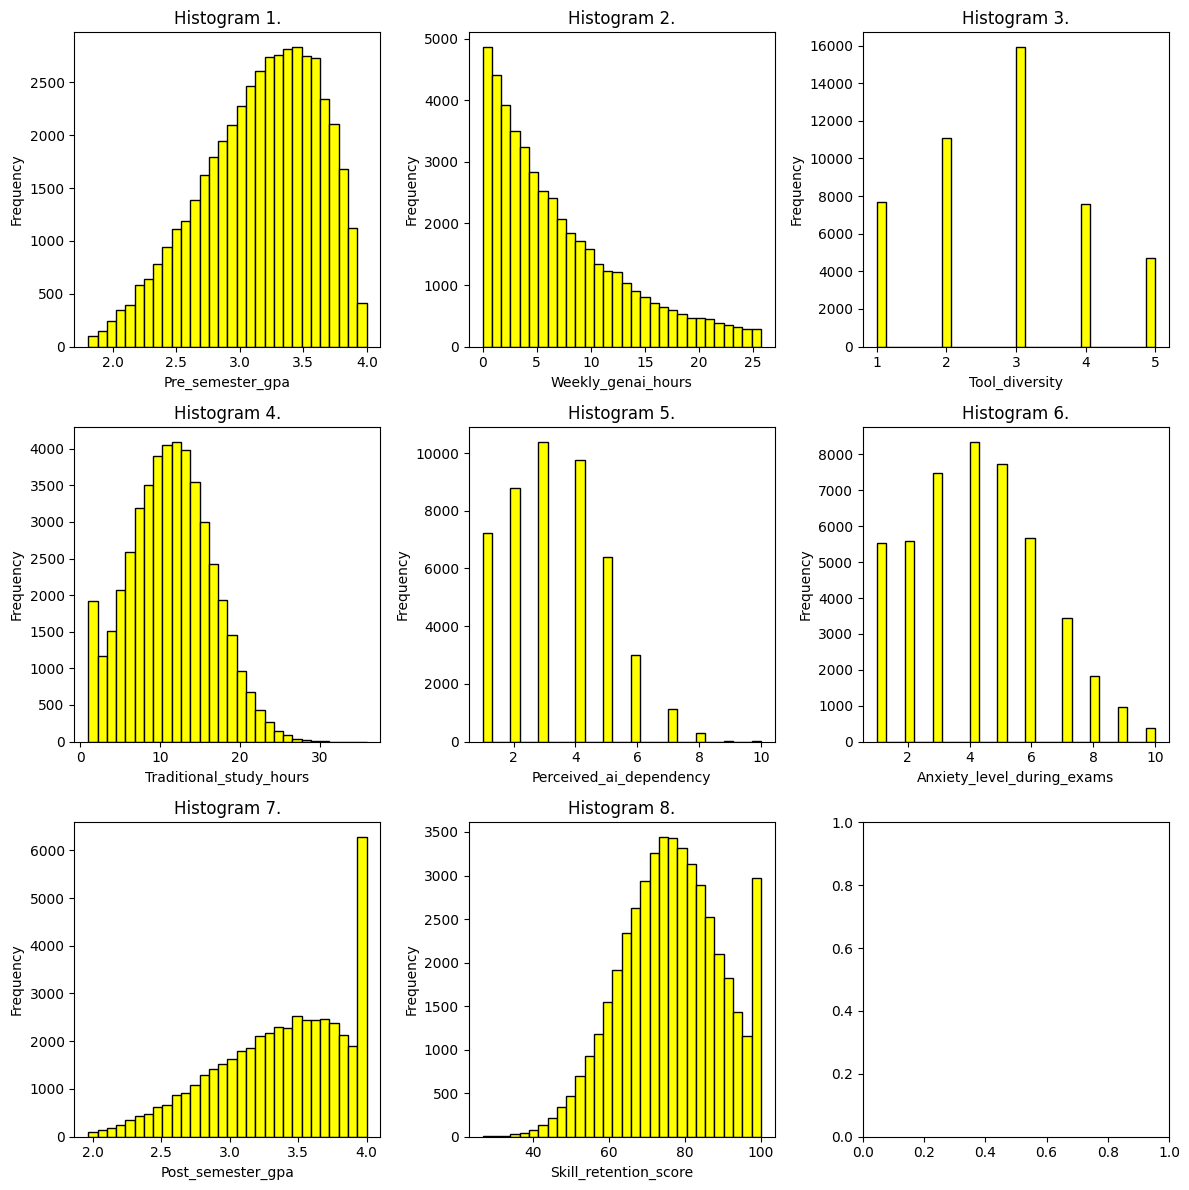

In [18]:
n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten() 

for index, column in enumerate(numeric_columns):
    axes[index].hist(df[column], bins=30, color='Yellow', edgecolor='black')
    axes[index].set_title(f'Histogram {index + 1}.')
    
    axes[index].set_xlabel(column.capitalize())
    axes[index].set_ylabel('Frequency')

plt.tight_layout()

plt.show()

### Detecting Class Imbalance

In [20]:
df.head()

,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,gpa_change,study_efficiency,gpa_change_status
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,0.08,stable
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,0.21,declined
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,0.11,improved
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,0.23,improved
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,0.17,improved


In [21]:
categorical_columns = df.select_dtypes(include=["str", "bool"]).columns.to_list()
categorical_columns

['major_category',
 'year_of_study',
 'primary_use_case',
 'prompt_engineering_skill',
 'paid_subscription',
 'institutional_policy',
 'burnout_risk_level',
 'gpa_change_status']

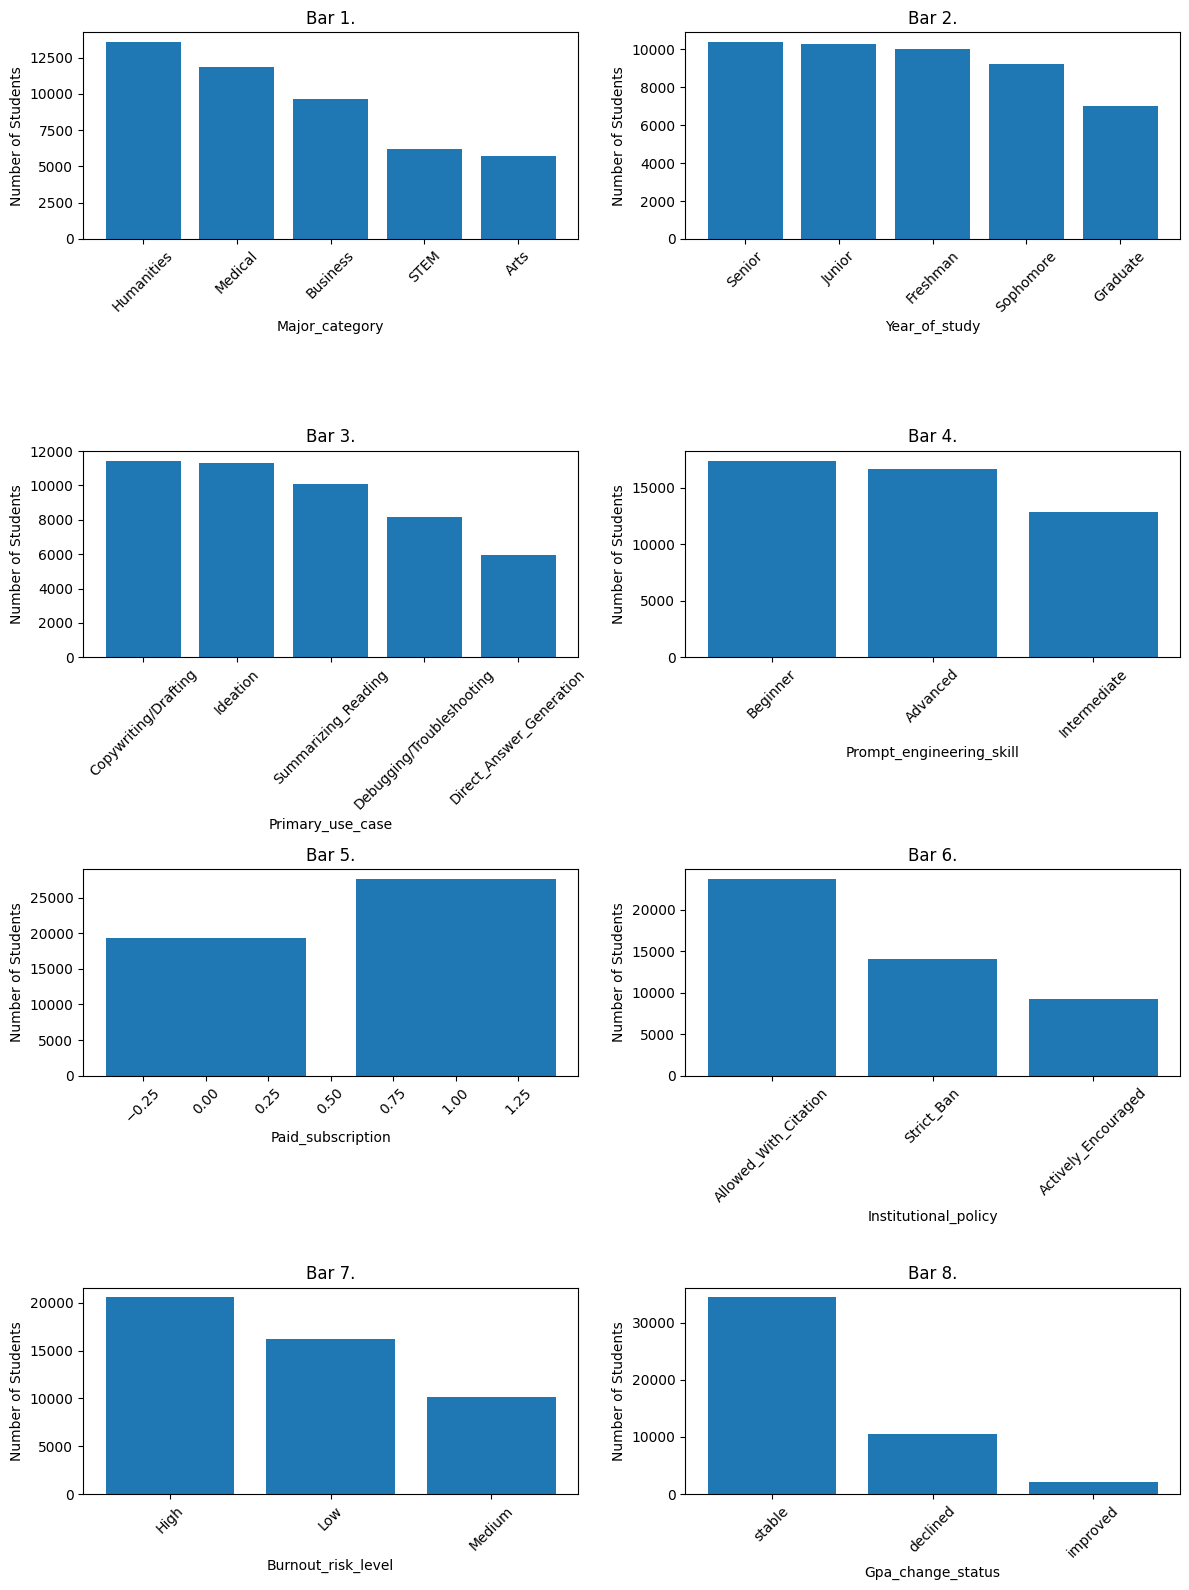

In [40]:
n_cols = 2
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten() 

data = df.loc[:, categorical_columns]

for index, column in enumerate(categorical_columns):
    axes[index].bar(data[column].unique(), data[column].value_counts())
    axes[index].set_title(f'Bar {index + 1}.')
    
    axes[index].set_xlabel(column.capitalize())
    axes[index].set_ylabel('Number of Students')    
    axes[index].tick_params("x", labelrotation=45)

plt.tight_layout()
plt.show()

In [42]:
df["gpa_change_status"].value_counts()

gpa_change_status
improved    34411
stable      10455
declined     2100
Name: count, dtype: int64

There is only one instance where class imbalance is clearly visible, and it appears in the 8th bar chart, which displays the number of students whose GPA either declined, improved, or stayed the same. It is evident that the vast majority-over 30,000 students-showed no improvement in their GPA after using AI. More strikingly, the number of students whose GPA decreased is roughly five times higher than those who actually managed to improve their scores.

### Feature Engineering – The "Delta" Effect

In [12]:
df["gpa_change"] = df["post_semester_gpa"] - df["pre_semester_gpa"]
df["study_efficiency"] = np.round(
    df["post_semester_gpa"] / (df["traditional_study_hours"] + df["weekly_genai_hours"]), decimals=2
)

In [13]:
df.head()

,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,gpa_change,study_efficiency
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,0.08
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,0.21
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,0.11
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,0.23
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,0.17


In [14]:
df.sort_values(by="gpa_change", ascending=False)

,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,gpa_change,study_efficiency
11235,111236,Business,Sophomore,2.591,2.78,Debugging/Troubleshooting,Advanced,4,False,21.33,4,Allowed_With_Citation,4,3.599,93.20,Medium,1.008,0.15
8124,108125,STEM,Freshman,2.941,7.31,Debugging/Troubleshooting,Advanced,3,False,12.03,4,Strict_Ban,1,3.926,87.56,Low,0.985,0.20
2059,102060,Business,Junior,2.268,7.72,Debugging/Troubleshooting,Advanced,3,True,25.80,5,Strict_Ban,6,3.208,100.00,Medium,0.940,0.10
28332,128333,Business,Sophomore,3.025,9.29,Debugging/Troubleshooting,Advanced,4,False,17.76,5,Actively_Encouraged,1,3.955,100.00,Low,0.930,0.15
9580,109581,STEM,Senior,3.023,11.53,Debugging/Troubleshooting,Advanced,4,True,14.13,4,Allowed_With_Citation,4,3.943,83.87,High,0.920,0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7936,107937,Business,Freshman,3.393,25.07,Direct_Answer_Generation,Intermediate,3,True,4.44,4,Allowed_With_Citation,3,2.776,56.82,Medium,-0.617,0.09
42186,142187,STEM,Sophomore,3.021,18.32,Direct_Answer_Generation,Advanced,4,True,2.40,6,Strict_Ban,7,2.400,92.49,Medium,-0.621,0.12
15962,115963,Business,Sophomore,3.139,22.09,Direct_Answer_Generation,Intermediate,3,True,1.00,9,Actively_Encouraged,6,2.483,77.83,Medium,-0.656,0.11
11260,111261,STEM,Graduate,3.102,19.96,Direct_Answer_Generation,Advanced,3,False,2.68,7,Strict_Ban,8,2.402,57.04,High,-0.700,0.11


In [15]:
def find_gpa_change_status(gpa_change: float) -> str:
    if -0.1 <= gpa_change <= 0.1: return "stable"
    if gpa_change <= -0.1: return "declined"
    if gpa_change > 0.1: return "improved"

df["gpa_change_status"] = df["gpa_change"].map(find_gpa_change_status)

In [16]:
df.head()

,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,gpa_change,study_efficiency,gpa_change_status
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,0.08,stable
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,0.21,declined
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,0.11,improved
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,0.23,improved
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,0.17,improved


### The GenAI GPA Paradox

I am going to eest whether students who use GenAI more than 10 hours/week have a statistically significant difference in `post_semester_gpa` compared to those who use it less than 2 hours/week. 10 and 2 are just number from my imagination, they could any number, but the point is to compare 2 extremes.

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 46966 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  46966 non-null  int64  
 1   major_category              46966 non-null  str    
 2   year_of_study               46966 non-null  str    
 3   pre_semester_gpa            46966 non-null  float64
 4   weekly_genai_hours          46966 non-null  float64
 5   primary_use_case            46966 non-null  str    
 6   prompt_engineering_skill    46966 non-null  str    
 7   tool_diversity              46966 non-null  int64  
 8   paid_subscription           46966 non-null  bool   
 9   traditional_study_hours     46966 non-null  float64
 10  perceived_ai_dependency     46966 non-null  int64  
 11  institutional_policy        46966 non-null  str    
 12  anxiety_level_during_exams  46966 non-null  int64  
 13  post_semester_gpa           46966 non-null  flo

In [47]:
more_10_less_2 = df[(df["weekly_genai_hours"] > 10) | (df["weekly_genai_hours"] < 2)]
more_10_less_2.head()

,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,gpa_change,study_efficiency,gpa_change_status
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,0.08,stable
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,0.21,declined
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,0.11,improved
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,0.23,improved
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High,-0.068,0.09,stable


In [49]:
def more_10_less_2_helper(value: int | float) -> str:
    return "less_2" if value <= 2 else "more_10"

more_10_less_2["status"] = more_10_less_2["weekly_genai_hours"].map(more_10_less_2_helper) 

In [51]:
(
    more_10_less_2
    .groupby(by="status")
    .agg(
        avg_presemester_gpa=("pre_semester_gpa", "mean"),
        avg_postsemeter_gpa=("post_semester_gpa", "mean")
    )
)

,avg_presemester_gpa,avg_postsemeter_gpa
status,,
less_2,3.159363,3.348275
more_10,3.161013,3.369712
